# Event Taxonomy + Predictive Value MVP

This notebook shows a **minimal, end-to-end prototype** for two things:

1. **Canonicalising noisy event names**  
   *We cluster similar strings (“Opened Email”, “Email Open”, “open email”) into a single `canonical_event` so models stay robust when names drift (for example, Klaviyo’s recent change from “Unsubscribed” to “Clicked email to unsubscribe”).*

2. **Quantifying each event’s lift on purchase probability**  
   *We train a lightweight LightGBM model that predicts “purchase in 7 days”, then rank events by mean absolute SHAP value to expose the most valuable touch-points and low-ROI noise.*

---

### How to run locally 
```bash
# from repo root
python -m pip install -r requirements.txt
jupyter notebook notebooks/01_taxonomy_value.ipynb
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from pathlib import Path
import event_taxonomy as et

pd.options.mode.chained_assignment = None

In [ ]:
df = et.load_events(Path("../data/raw_events.csv"))
df = et.canonicalise(df)
X, y = et.build_feature_matrix(df)
model, shap_top = et.train_value_model(X, y)

In [3]:
shap_top

,feature,mean_abs_shap
1,ev_1,2.252788
13,ev_8,0.065444
16,is_brand_action,0.054125
3,ev_11,0.047327
11,ev_6,0.045296
15,n_events_24h,0.044506
5,ev_13,0.041444
0,ev_0,0.037926
12,ev_7,0.036730
4,ev_12,0.035974


<Axes: ylabel='feature'>

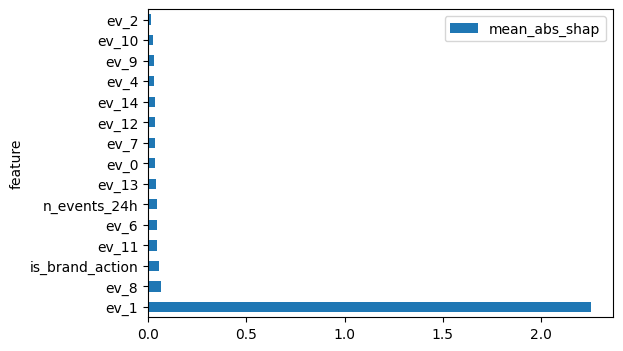

In [4]:
shap_top.plot.barh(x="feature", y="mean_abs_shap", figsize=(6,4))

In [5]:
def representative_event(df, canon_col="canonical_event", text_col="event_name"):
    rep = (
        df.groupby(canon_col)[text_col]
          .agg(lambda x: x.value_counts().idxmax())
          .to_dict()
    )
    return rep

id_to_name = representative_event(df)

def map_feature_to_label(feat: str) -> str:
    if feat.startswith("ev_"):
        ev_id = int(feat.replace("ev_", ""))
        return id_to_name.get(ev_id, f"event_{ev_id}")
    return feat

shap_top["event_name"] = shap_top["feature"].apply(map_feature_to_label)

display(
    shap_top[["event_name", "mean_abs_shap"]]
        .rename(columns={"mean_abs_shap": "mean |SHAP|"})
        .style.bar(subset=["mean |SHAP|"], color="#5fba7d")
)

,event_name,mean |SHAP|
1,Order Placed,2.252788
13,Clicked Email,0.065444
16,is_brand_action,0.054125
3,Clicked email to unsubscribe,0.047327
11,Email Open,0.045296
15,n_events_24h,0.044506
5,Blotout Viewed Product Xyz,0.041444
0,Unsubscribed,0.037926
12,Opened Email,0.036730
4,Octane: Quiz Completed: Find The Perfect Eye Shadow .,0.035974


In [6]:
centroids = (
    df.groupby("canonical_event")["vec"]
      .apply(lambda v: np.vstack(v).mean(axis=0))
)
sim = cosine_similarity(centroids.tolist())

In [7]:
(pd.Series(id_to_name)
   .rename("canonical_label")
   .to_csv("../data/canonical_event_map.csv"))

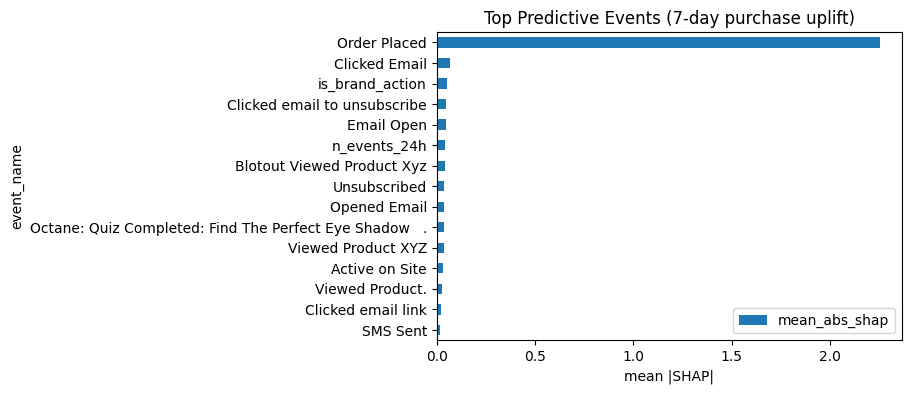

In [22]:
shap_top.sort_values("mean_abs_shap").plot.barh(
        x="event_name", y="mean_abs_shap", figsize=(6,4))
plt.title("Top Predictive Events (7-day purchase uplift)")
plt.xlabel("mean |SHAP|")
plt.legend(loc="lower right")
plt.savefig("figures/event_value_bar.png", dpi=150)

## Hand-label customer vs brand actions

In [9]:
events = (
    pd.read_csv("../data/raw_events.csv")
      ["event_name"]
      .str.strip()
      .value_counts()
      .reset_index(name="freq")
      .rename(columns={"index": "event_name"})
)

In [10]:
events.head(100)

,event_name,freq
0,Order Placed,1301
1,Black Crow Identified,1299
2,Viewed Product XYZ,1290
3,Email Open,1268
4,Viewed Product.,1264
5,Opened Email,1258
6,Blotout Viewed Product Xyz,1257
7,Placed Order,1256
8,Clicked email link,1251
9,Octane: Quiz Completed: Find The Perfect Eye S...,1237


In [11]:
total_events = events.freq.sum()
print(total_events)

20000


In [12]:
events.head(100).to_csv("../data/top_events.csv", index=False)

#### Looking at Long-Tail Events

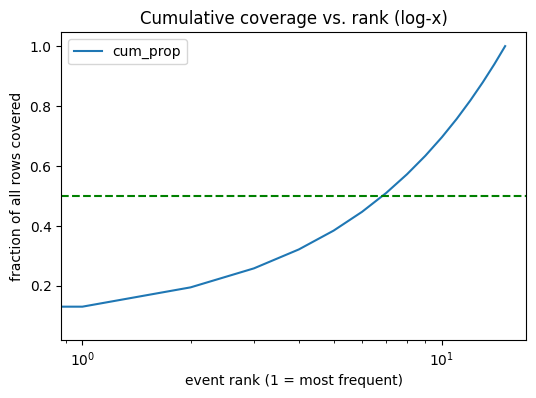

In [13]:
events["cum_prop"] = events["freq"].cumsum() / total_events

events.plot(
    y="cum_prop",
    use_index=True,
    logx=True,
    figsize=(6,4),
    title="Cumulative coverage vs. rank (log-x)"
)
plt.axhline(0.50, color="g", ls="--");
plt.ylabel("fraction of all rows covered")
plt.xlabel("event rank (1 = most frequent)")
plt.show()


In [14]:
from kneed import KneeLocator

x = np.arange(1, len(events) + 1)
y = events["cum_prop"].values
kl = KneeLocator(x, y, curve="convex", direction="increasing", S=1.0)

if kl.knee is None:
    target_cov = 0.90
    freq_cut = events.loc[events["cum_prop"] >= target_cov, "freq"].iloc[0]
    print(f"No knee found; using 90 % coverage → freq ≥ {freq_cut}")
else:
    freq_cut = events.iloc[kl.knee - 1]["freq"]
    print(f"Knee at rank {kl.knee} → freq ≥ {freq_cut}")

Knee at rank 16 → freq ≥ 1204


In [15]:
common   = events.query("freq >= @freq_cut")
longtail = events.query("freq <  @freq_cut")

In [16]:
top16     = events.query("freq >= @freq_cut")
coverage  = top16["freq"].sum() / total_events

print(f"\n{len(top16)} names cover {coverage:.1%} of all rows\n")
display(top16)


16 names cover 100.0% of all rows



,event_name,freq,cum_prop
0,Order Placed,1301,0.06505
1,Black Crow Identified,1299,0.13000
2,Viewed Product XYZ,1290,0.19450
3,Email Open,1268,0.25790
4,Viewed Product.,1264,0.32110
5,Opened Email,1258,0.38400
6,Blotout Viewed Product Xyz,1257,0.44685
7,Placed Order,1256,0.50965
8,Clicked email link,1251,0.57220
9,Octane: Quiz Completed: Find The Perfect Eye S...,1237,0.63405


In [17]:
top16.to_csv("../data/label_these_events.csv", index=False)

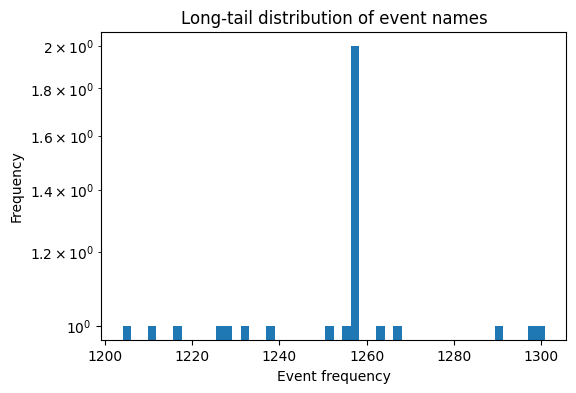

In [18]:
plt.figure(figsize=(6,4))
events["freq"].plot.hist(bins=50, log=True)
plt.xlabel("Event frequency")
plt.title("Long-tail distribution of event names")
plt.show()

#### View the parquet file

In [19]:
import duckdb

df = duckdb.query("""
    SELECT canonical_event, COUNT(*) AS n
    FROM read_parquet('../data/value_features.parquet')
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 10
""").df()

print(df.head())

   canonical_event     n
0                1  2557
1                5  1299
2               14  1290
3                6  1268
4                9  1264
